# Fase 4: EDA y entendimiento del dominio

## 4.1 EDA del target (gold_spot)

- Serie larga con **tendencia alcista estructural** (1979 -> 2025) y **cambios de régimen** (2008, 2011, 2020, 2024).
- Precio en niveles: NO es estacionaria (ADF con p>0.05). Los retornos logarítmicos sí lo son.
- Volatilidad agrupada (*volatility clustering*), típica de activos financieros.

## 4.2 EDA de features

- Correlación esperada con el dólar (DXY) negativa y con tipos reales negativa.
- Muchas features correlacionadas entre sí (metales, índices) -> redundancia.

## 4.3 EDA específico de series temporales

- Tendencia, estacionalidad semanal débil, autocorrelación alta en niveles y casi nula en retornos.

## 4.4 Hipótesis

1. Los **lags y retornos** del propio oro dominarán la predicción a 1 día.
2. DXY, tipos reales y VIX aportan señal exógena a horizontes medios.
3. La métrica más informativa para el usuario es **MAE/sMAPE** (USD por onza).
4. El split debe ser **temporal estricto**; los retornos permiten un modelo más estable.
5. Riesgo principal: *non-stationarity* -> los modelos de árboles con lags gestionan niveles; los lineales requieren retornos.

---


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root():
    p = Path.cwd()
    for _ in range(5):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    return Path.cwd()

ROOT = _find_root()
sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga y limpieza del dataset para EDA.

Reutilizamos el pipeline de limpieza (`clean_daily_series`) que: recorta a
la ventana 2000-2025, elimina fines de semana, excluye features con
cobertura insuficiente y hace forward-fill (solo pasado).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.config import get_config
from src.data.load_data import clean_daily_series, load_raw
from src.utils import save_fig

cfg = get_config()
raw = load_raw(cfg)
df = clean_daily_series(raw, cfg)
print("Filas tras limpieza:", len(df), "| columnas:", df.shape[1])
print("Rango:", df["date"].min().date(), "->", df["date"].max().date())

  [clean] filas con target: 6705 (descartadas 0)
Filas tras limpieza: 6705 | columnas: 42
Rango: 2000-01-03 -> 2025-09-12


Estadísticos descriptivos del target.

Media, desviación, cuartiles, asimetría y curtosis del precio del oro en la
ventana 2000-2025. La asimetría positiva y la alta curtosis son típicas de
activos con rallies (cola derecha).

In [3]:
g = df["gold_spot"]
print(g.describe().round(2).to_string())
print("Asimetría:", round(stats.skew(g), 2), "| Curtosis:", round(stats.kurtosis(g), 2))

count    6705.00
mean     1191.92
std       671.38
min       255.55
25%       596.00
50%      1233.59
75%      1650.35
max      3643.13
Asimetría: 0.63 | Curtosis: 0.55


Gráfico del target: niveles y retornos logarítmicos.

- Panel superior izquierdo: precio en niveles (tendencia alcista + regímenes).
- Panel superior derecho: retorno log diario (volatilidad variable).
- Paneles inferiores: histogramas de niveles y retornos (cola ancha en retornos).

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_target.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/eda_target.png')

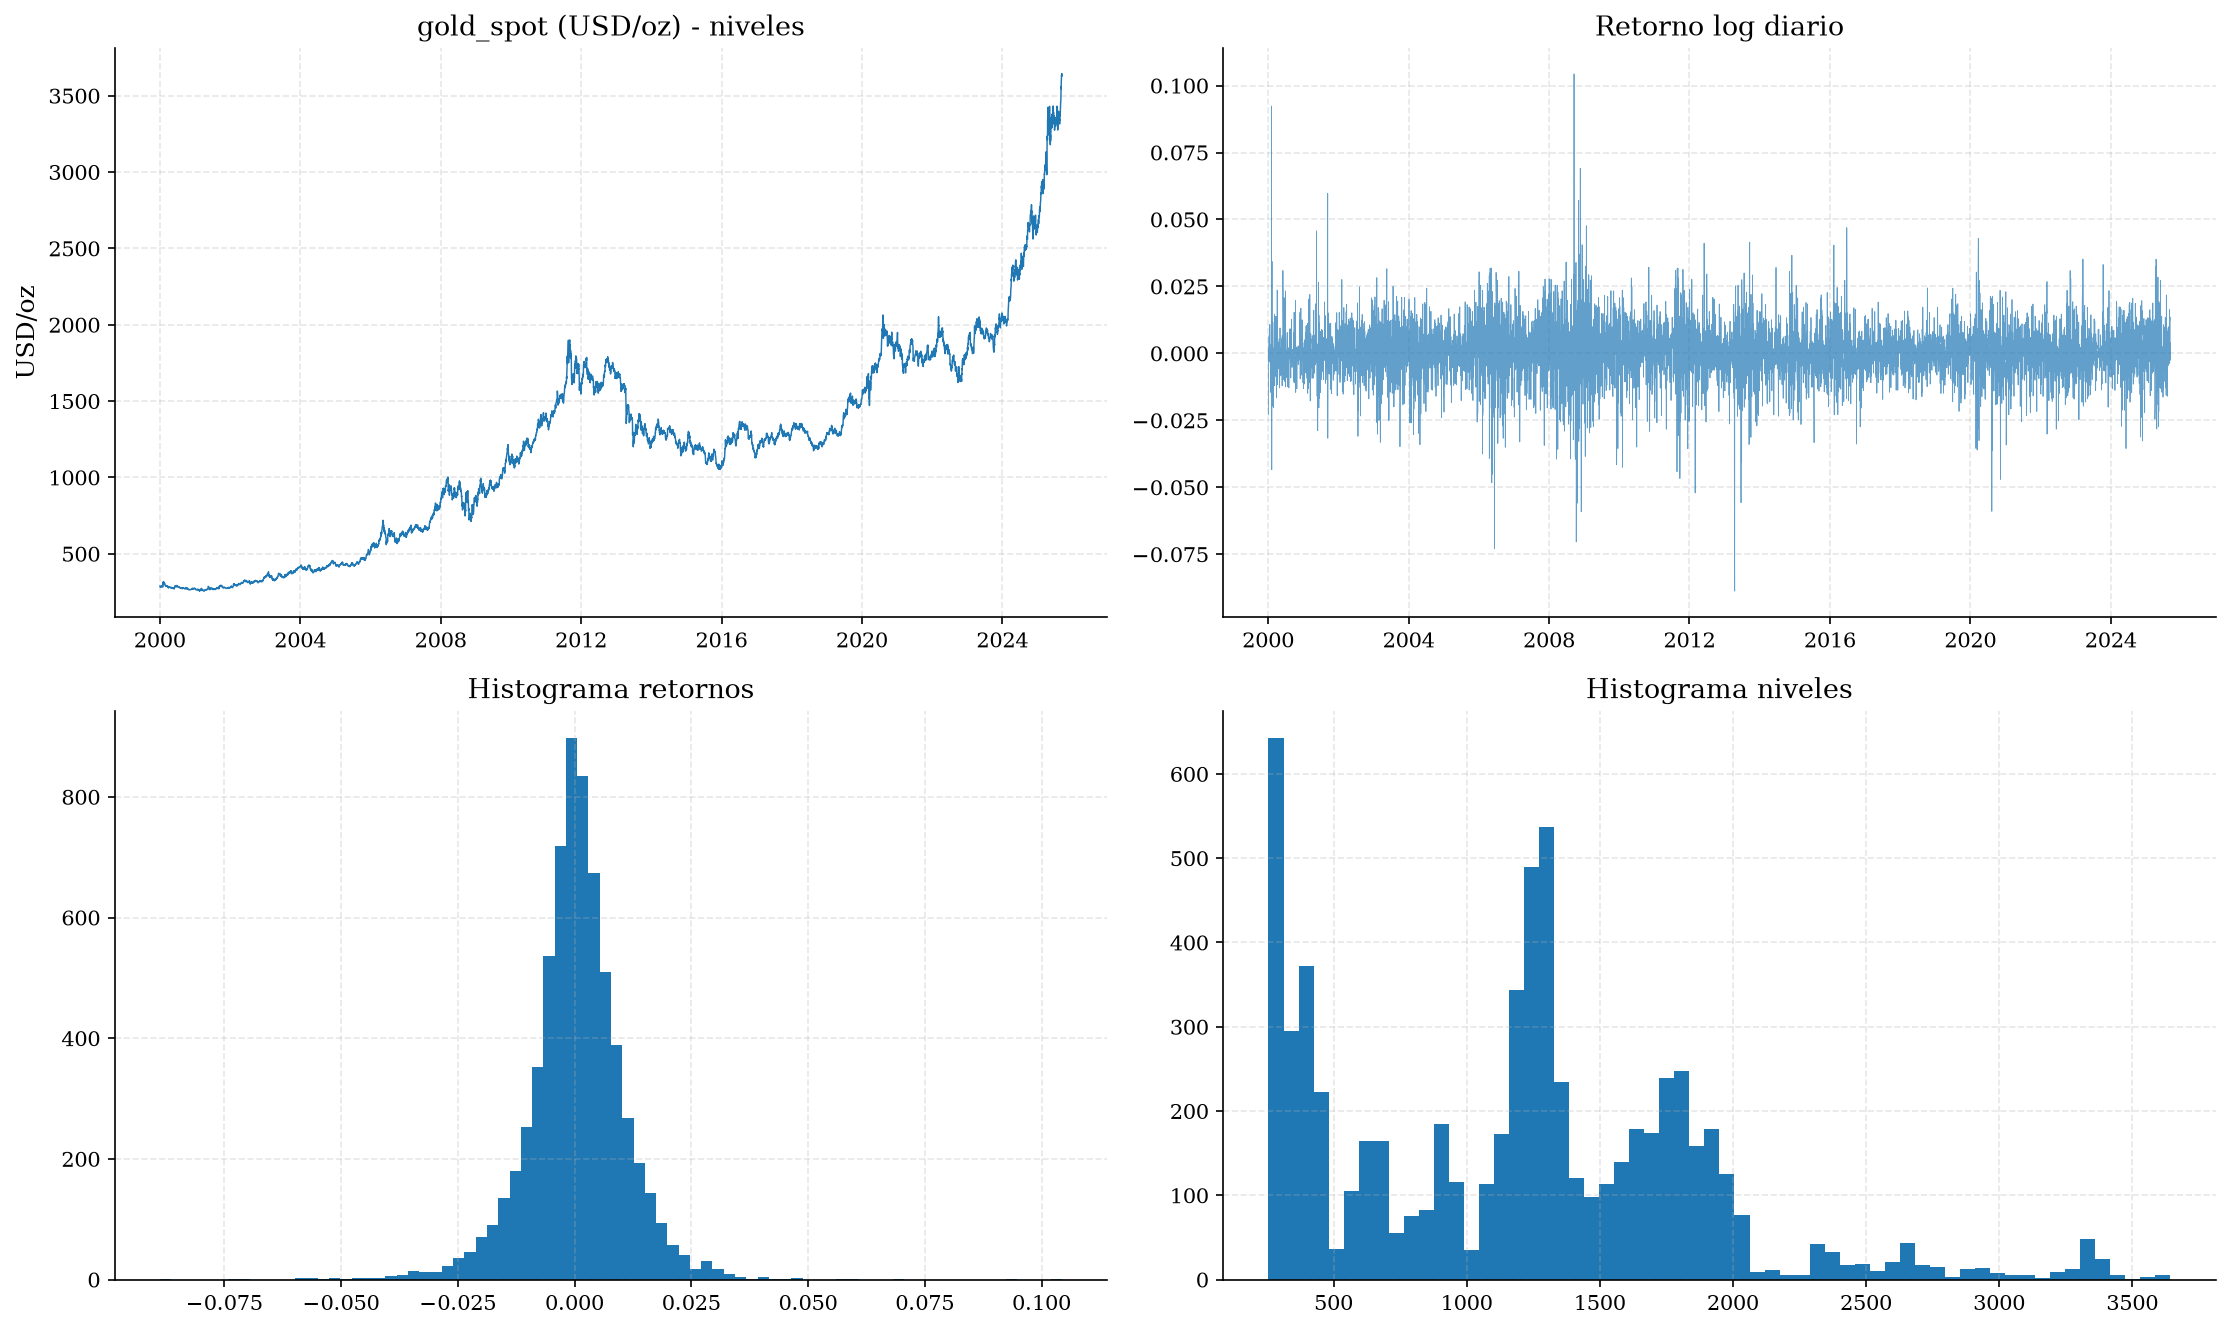

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes[0, 0].plot(df["date"], g, lw=0.7)
axes[0, 0].set_title("gold_spot (USD/oz) - niveles")
axes[0, 0].set_ylabel("USD/oz")

rets = np.log(g).diff().dropna()
axes[0, 1].plot(df["date"].iloc[1:], rets, lw=0.4, alpha=0.7)
axes[0, 1].set_title("Retorno log diario")

axes[1, 0].hist(rets, bins=80)
axes[1, 0].set_title("Histograma retornos")

axes[1, 1].hist(g, bins=60)
axes[1, 1].set_title("Histograma niveles")
fig.tight_layout()
save_fig(fig, "eda_target.png")

Análisis de estacionariedad (test ADF).

El test Augmented Dickey-Fuller contrasta H0: la serie tiene raíz unitaria
(no estacionaria). Si p < 0.05 rechazamos H0 (serie estacionaria).
En niveles el oro NO es estacionario (p alto); en retornos SÍ (p < 0.01).

In [5]:
from statsmodels.tsa.stattools import adfuller

for name, s in [("niveles", g.dropna()), ("retornos", rets.dropna())]:
    adf, p = adfuller(s)[:2]
    print(f"ADF {name}: stat={adf:.2f}, p={p:.4f} -> "
          f"{'estacionaria' if p < 0.05 else 'NO estacionaria'}")

ADF niveles: stat=2.91, p=1.0000 -> NO estacionaria
ADF retornos: stat=-82.85, p=0.0000 -> estacionaria


Autocorrelación: niveles vs retornos.

- ACF de niveles: decae muy lentamente (persistencia extrema, ~1 en lag 1).
- ACF de retornos: ruido blanco (sin autocorrelación) -> el signo diario es
  casi impredecible; de ahí la importancia de los lags para el nivel.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_acf.png
[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_pacf.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/eda_pacf.png')

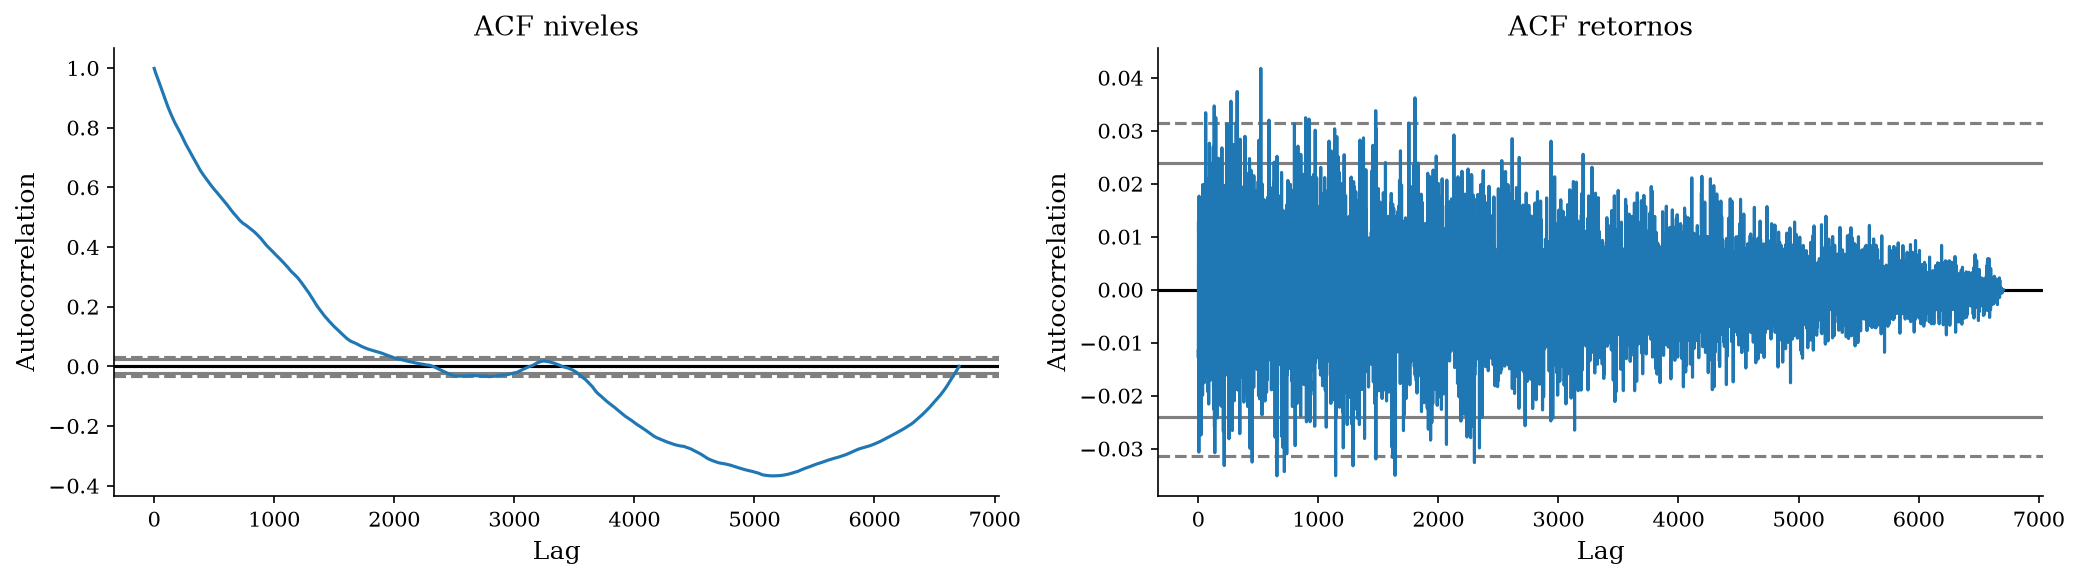

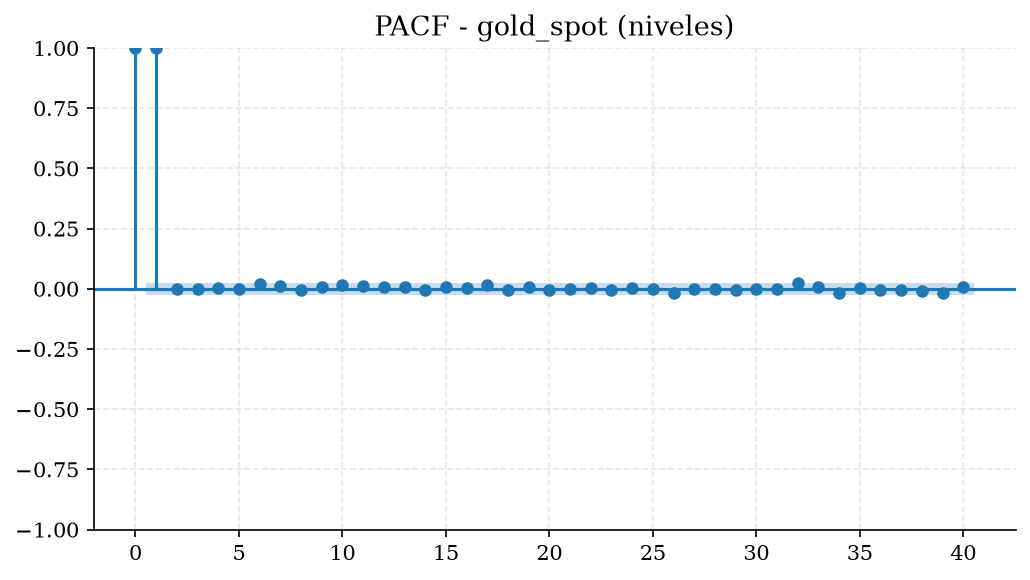

In [6]:
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
autocorrelation_plot(g, ax=axes[0])
axes[0].set_title("ACF niveles")
autocorrelation_plot(rets, ax=axes[1])
axes[1].set_title("ACF retornos")
fig.tight_layout()
save_fig(fig, "eda_acf.png")
# PACF (autocorrelación parcial): mide la correlación de gold_spot(t) con
# gold_spot(t-k) controlando por los lags intermedios. Identifica el orden
# de un posible proceso AR.
from statsmodels.graphics.tsaplots import plot_pacf

fig_pacf, ax_pacf = plt.subplots(figsize=(7, 4))
plot_pacf(g.dropna(), lags=40, ax=ax_pacf, method='ywm')
ax_pacf.set_title('PACF - gold_spot (niveles)')
fig_pacf.tight_layout()
save_fig(fig_pacf, 'eda_pacf.png')


Correlaciones con el target (niveles y retornos).

- Niveles: el oro correlaciona alto con plata, metales e índices de materias
  primas; negativo con el dólar (DXY) y tipos reales.
- Retornos: correlaciones mucho más débiles (señal diaria pequeña).

In [7]:
exog = [c for c in df.columns if c not in ("date", "gold_spot")]
corr_levels = df[exog].corrwith(g).sort_values(ascending=False)
print("Top correlaciones con gold_spot (niveles):")
print(corr_levels.head(8).round(3).to_string())
print("\nPeores correlaciones (niveles):")
print(corr_levels.tail(5).round(3).to_string())

ret_df = df.copy()
ret_df["gold_ret"] = rets
corr_rets = ret_df[exog].corrwith(ret_df["gold_ret"])
print("\nTop correlaciones retorno oro vs retornos exógenas:")
print(corr_rets.sort_values(ascending=False).head(10).round(3).to_string())
# Correlación de Spearman (no paramétrica): robusta a outliers y relaciones
# monotónicas no lineales. Complementa a Pearson.
corr_spearman = df[exog].corrwith(g, method='spearman').sort_values(ascending=False)
print(chr(10) + 'Top correlaciones Spearman con gold_spot (niveles):')
print(corr_spearman.head(8).round(3).to_string())
print(chr(10) + 'Peores correlaciones Spearman (niveles):')
print(corr_spearman.tail(5).round(3).to_string())


Top correlaciones con gold_spot (niveles):
gold_futures          1.000
export_price_index    0.996
us_cpi                0.929
us_gdp                0.903
silver_futures        0.885
silver_spot           0.883
us_m2                 0.879
us_retail_sales       0.862

Peores correlaciones (niveles):
us10y_real              -0.460
us10y_yield             -0.467
us_consumer_sentiment   -0.553
consumer_confidence     -0.575
usdcny_exchange         -0.627

Top correlaciones retorno oro vs retornos exógenas:
policy_uncertainty       0.027
us10y_real               0.022
usdcny_exchange          0.019
fed_funds                0.018
silver_spot              0.016
gold_futures             0.015
silver_futures           0.014
commodities_crb          0.013
commodities_bloomberg    0.012
us2y_yield               0.010

Top correlaciones Spearman con gold_spot (niveles):
gold_futures          1.000
export_price_index    0.994
silver_futures        0.927
silver_spot           0.926
us_cpi           

Estacionalidad mensual y volatilidad agrupada.

- Precio medio por mes: estacionalidad débil (el oro no tiene un mes claramente
  dominante, aunque octubre-enero suelen ser fuertes).
- Volatilidad anualizada (ventana 21d): claramente agrupada (2008, 2011-13,
  2020, 2024-25), típico de activos financieros.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_seasonal.png


[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_vol.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/eda_vol.png')

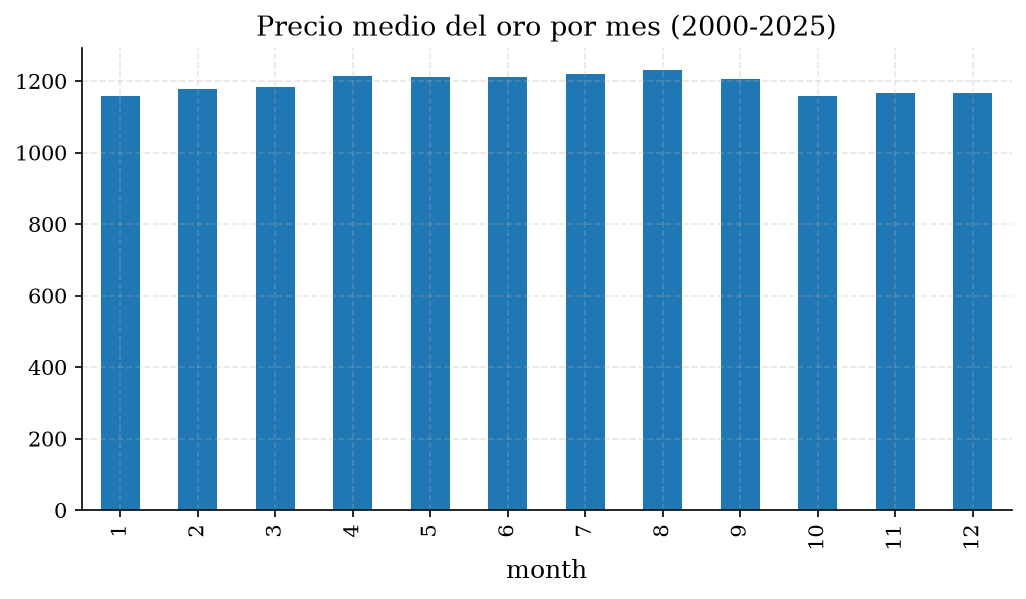

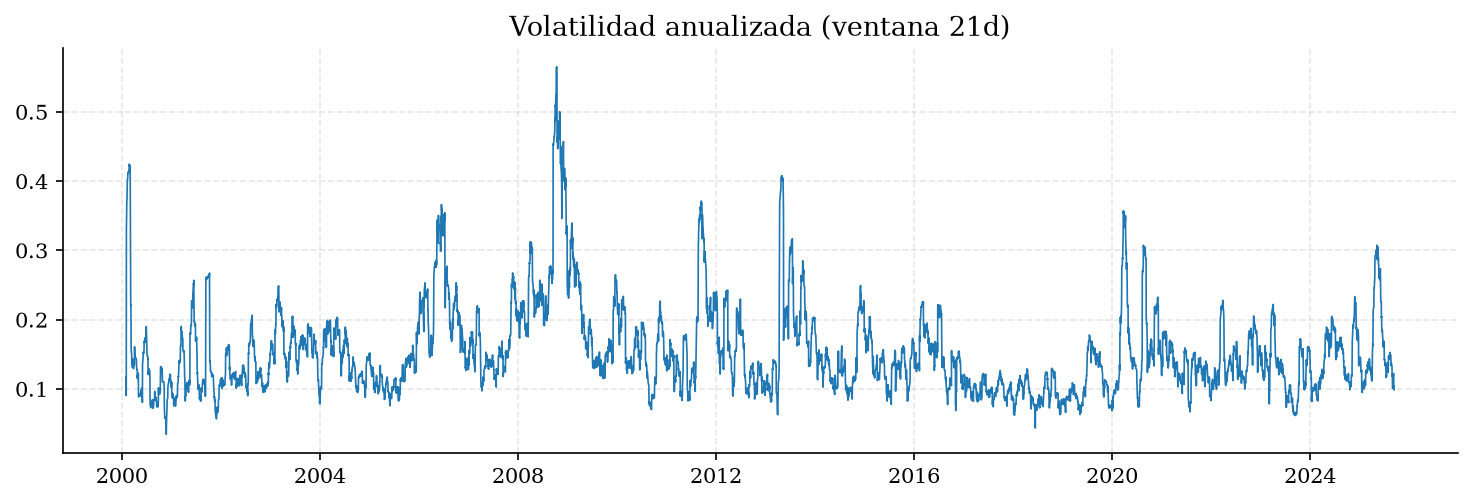

In [8]:
df["month"] = df["date"].dt.month
monthly = df.groupby("month")["gold_spot"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
monthly.plot(kind="bar", ax=ax)
ax.set_title("Precio medio del oro por mes (2000-2025)")
save_fig(fig, "eda_seasonal.png")

vol21 = rets.rolling(21).std() * np.sqrt(252)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df["date"].iloc[1:], vol21, lw=0.8)
ax.set_title("Volatilidad anualizada (ventana 21d)")
save_fig(fig, "eda_vol.png")

Mapa de correlaciones entre features (heatmap).

Muchas variables financieras están altamente correlacionadas entre sí
(metales, índices, tipos). Esto informa la selección de features por
redundancia (fase 10): eliminaremos pares con |rho| > 0.98.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_corr_heatmap.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction-v2/reports/figures/eda_corr_heatmap.png')

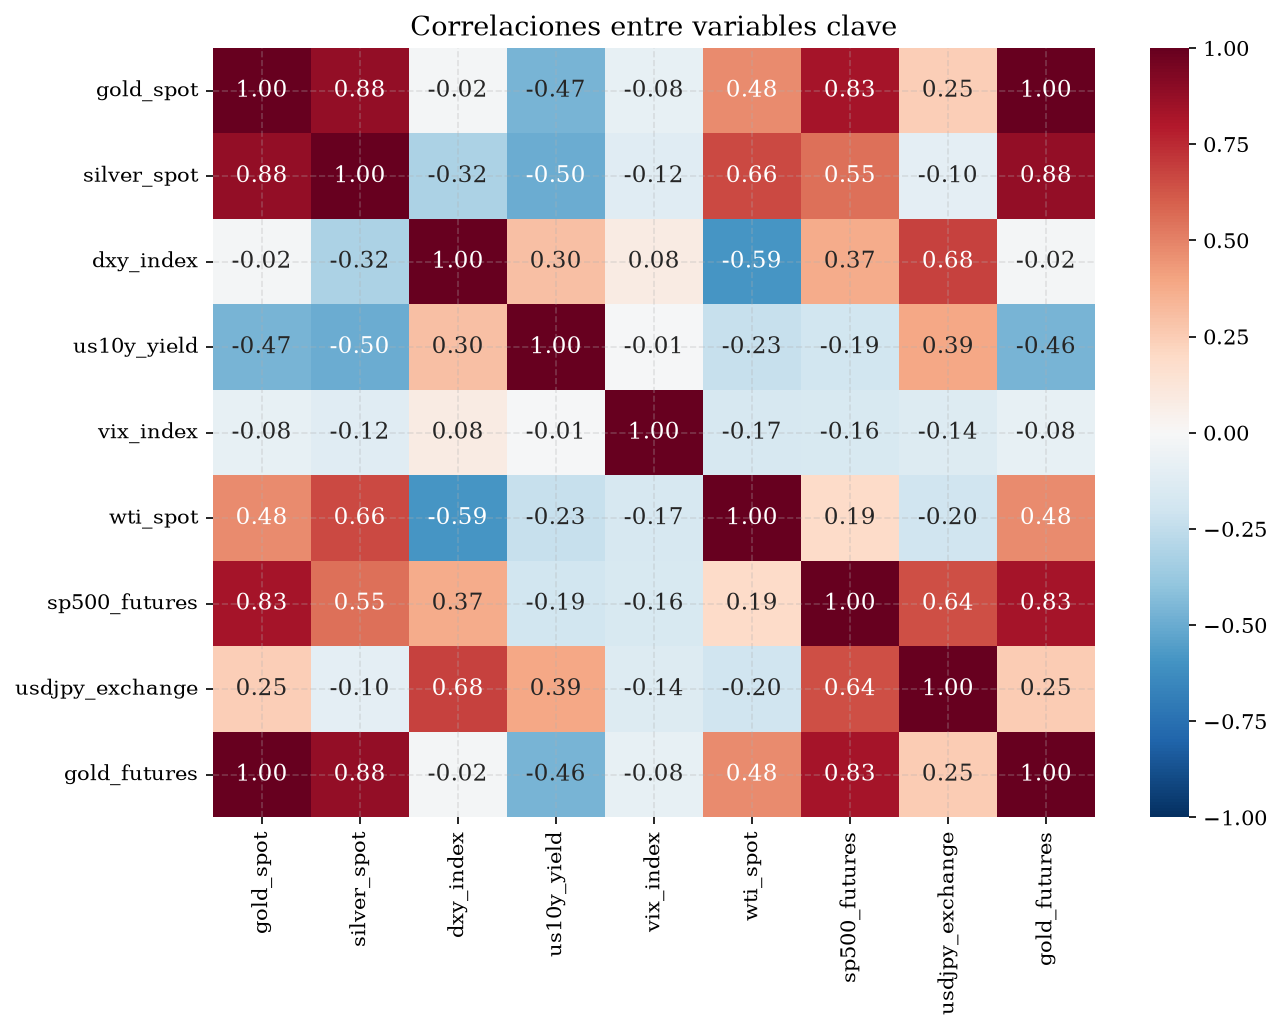

In [9]:
import seaborn as sns

# Solo features presentes en el dataset limpio (algunas se excluyeron por cobertura)
available = [c for c in ["gold_spot", "silver_spot", "dxy_index", "us10y_yield",
                           "vix_index", "wti_spot", "sp500_futures", "bitcoin_price",
                           "usdjpy_exchange", "gold_futures"] if c in df.columns]
key = available or ["gold_spot", "silver_spot", "dxy_index", "us10y_yield"]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[key].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlaciones entre variables clave")
plt.tight_layout()
save_fig(fig, "eda_corr_heatmap.png")

## Análisis de relaciones bivariadas: scatterplots y pairplot

Complementamos el EDA con visualizaciones de relaciones entre pares de
variables, siguiendo el estilo de análisis exploratorio riguroso:

- **Scatterplots**: relación del target (gold_spot) con las variables más
  relevantes (plata, DXY, petróleo, tipos). Se observa la estructura de la
  relación (lineal, no lineal, con cambios de régimen).
- **Pairplot**: matriz compacta de relaciones bivariadas entre 4 variables
  representativas, con distribuciones en la diagonal.


[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_scatterplots.png


[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_pairplot.png
Pairplot guardado: reports/figures/eda_pairplot.png


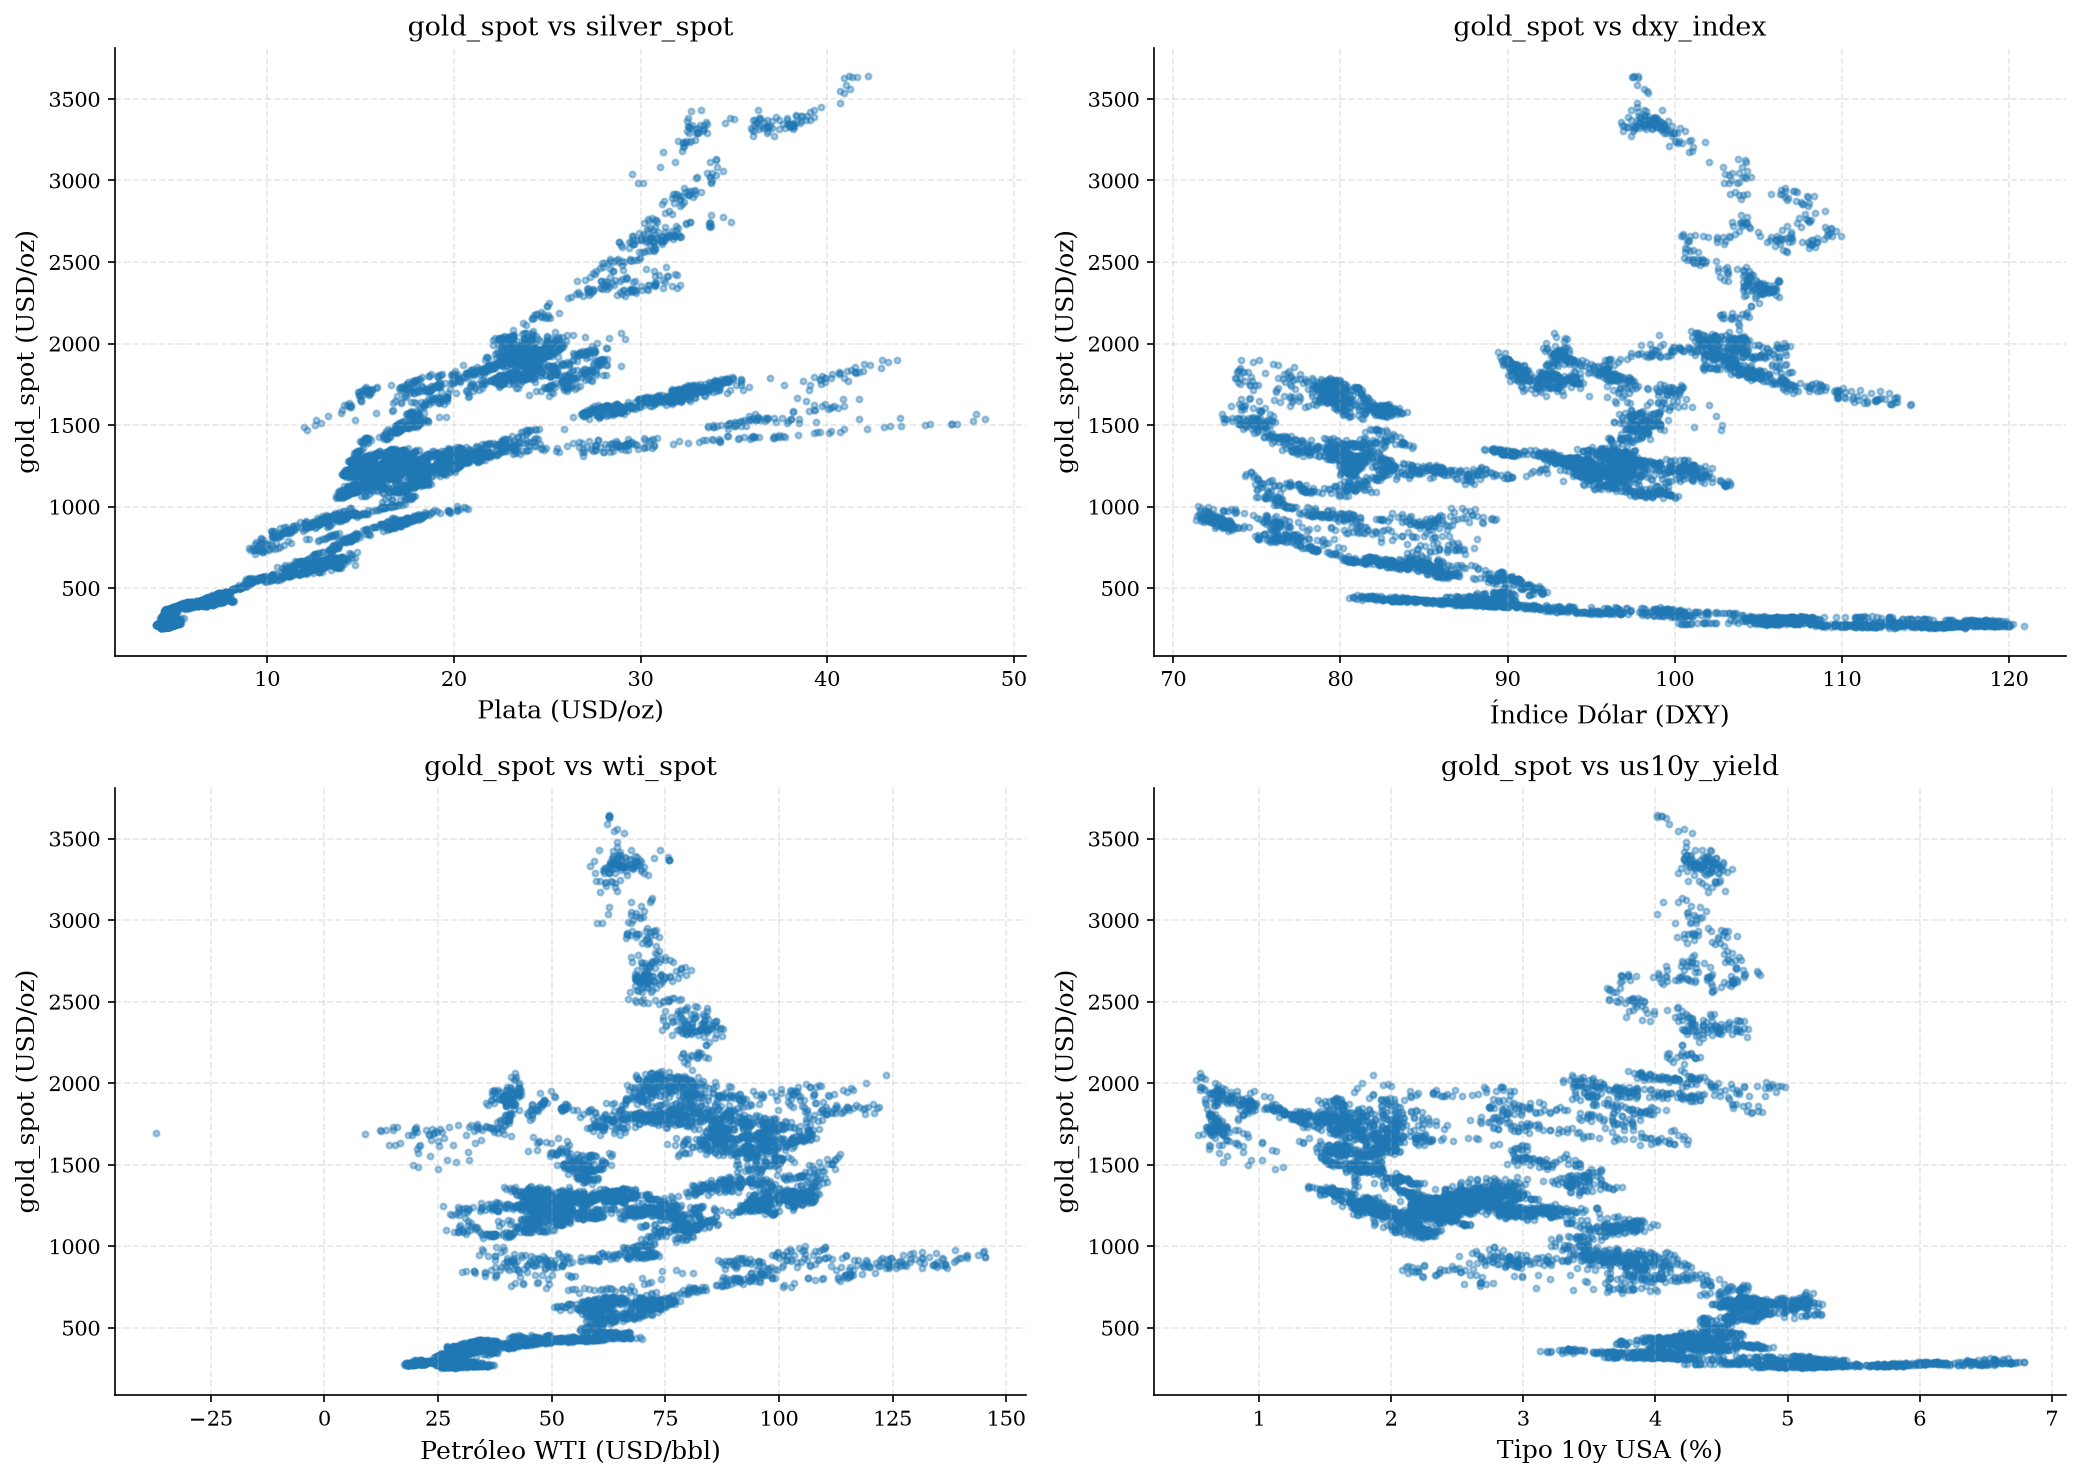

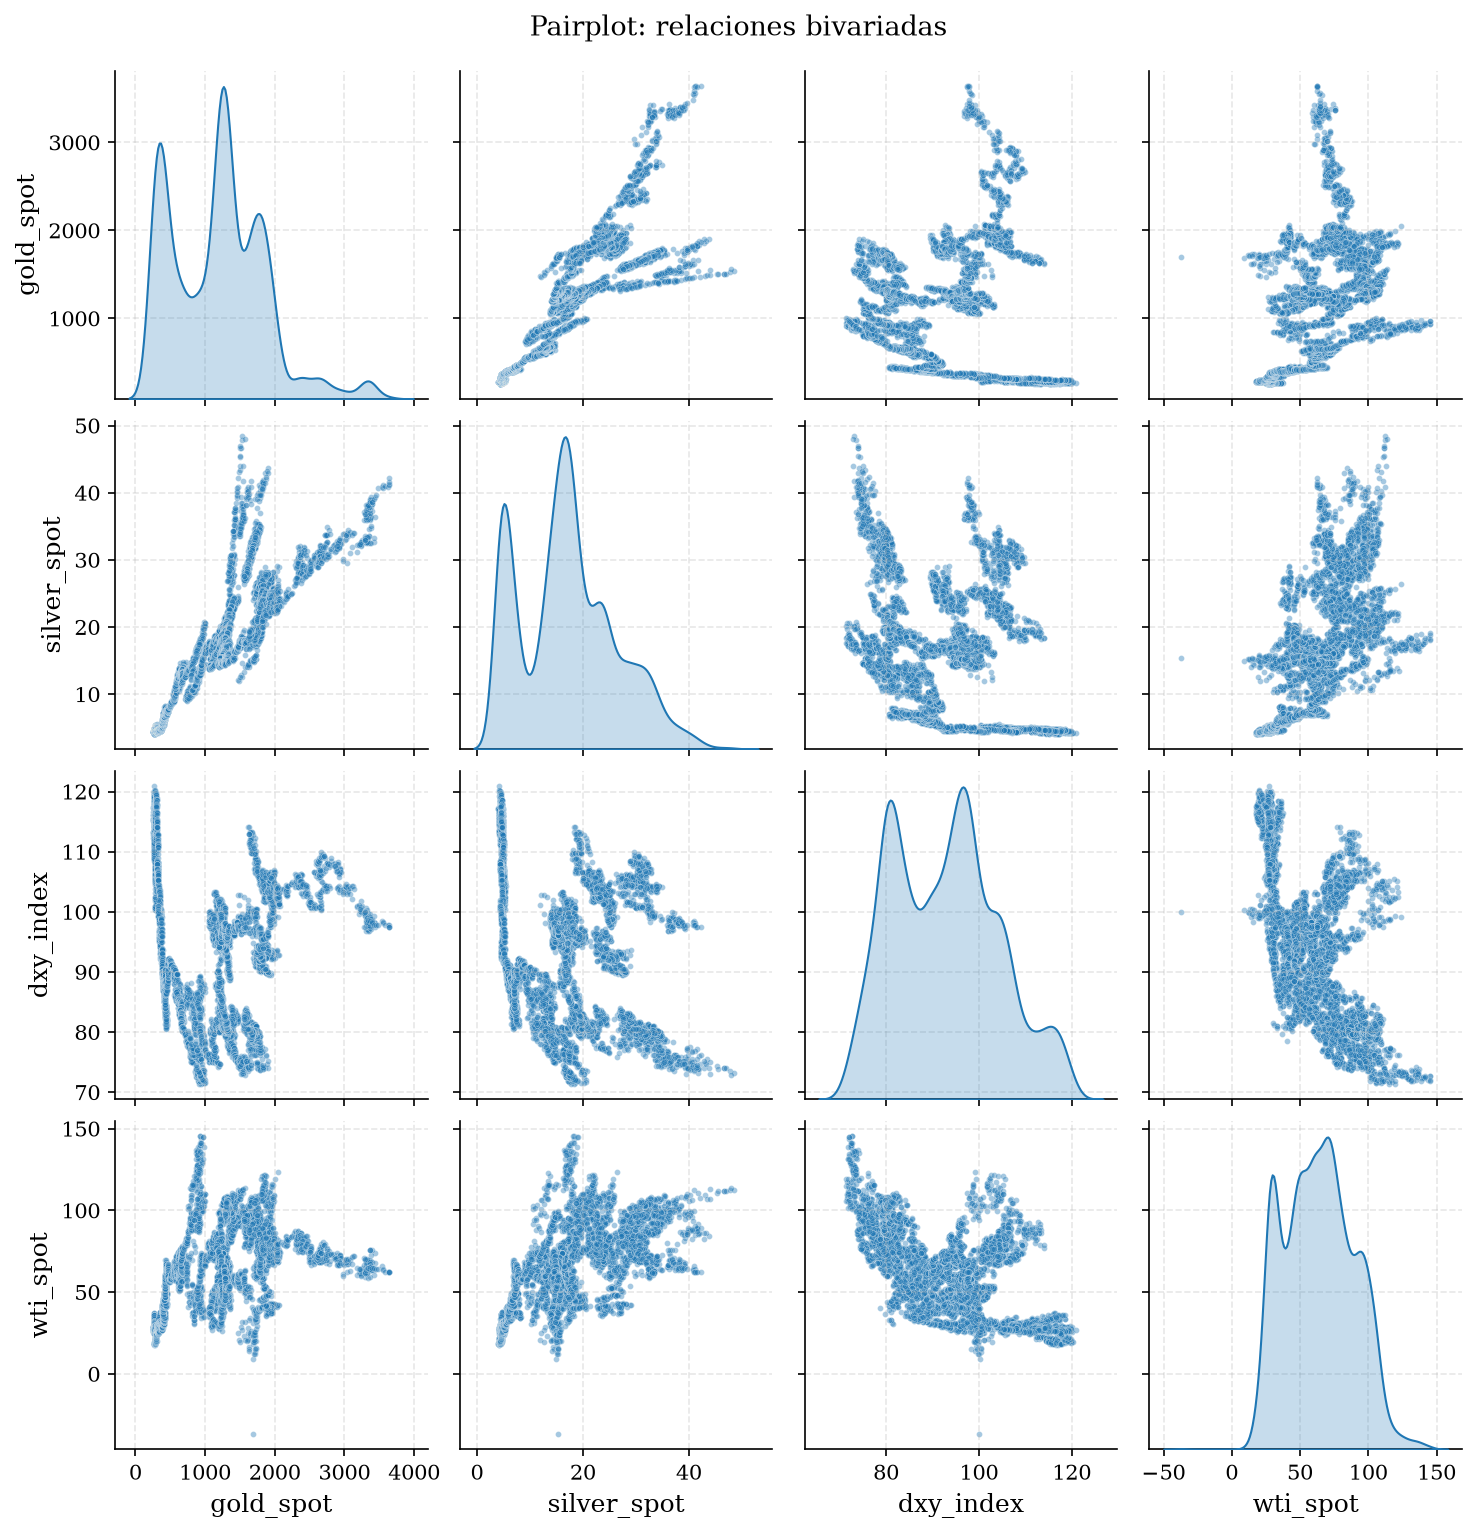

In [10]:
# Scatterplots: gold_spot vs variables clave
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
pares = [("silver_spot", "Plata (USD/oz)"),
         ("dxy_index", "Índice Dólar (DXY)"),
         ("wti_spot", "Petróleo WTI (USD/bbl)"),
         ("us10y_yield", "Tipo 10y USA (%)")]
for ax, (col, label) in zip(axes.flat, pares):
    if col in df.columns:
        ax.scatter(df[col], df["gold_spot"], s=8, alpha=0.4)
        ax.set_xlabel(label)
        ax.set_ylabel("gold_spot (USD/oz)")
        ax.set_title(f"gold_spot vs {col}")
fig.tight_layout()
save_fig(fig, "eda_scatterplots.png")

# Pairplot reducido (4 variables representativas)
import seaborn as sns
pair_cols = [c for c in ["gold_spot", "silver_spot", "dxy_index", "wti_spot"] if c in df.columns]
if len(pair_cols) == 4:
    g = sns.pairplot(df[pair_cols], diag_kind="kde", plot_kws={"s": 8, "alpha": 0.4})
    g.fig.suptitle("Pairplot: relaciones bivariadas", y=1.02)
    save_fig(g.fig, "eda_pairplot.png")
    print("Pairplot guardado: reports/figures/eda_pairplot.png")


## Distribuciones de features (histogramas + KDE), boxplot y outliers

- **Histogramas + KDE** de las variables más relevantes: se observa la
  asimetría y multimodalidad típicas de series financieras.
- **Boxplot** del target: identificación visual de outliers (valores extremos
  que, en series con tendencia, son en realidad cambios de régimen).
- **Detección de outliers** con rango intercuartílico (IQR) y z-score:
  se cuantifica cuántos valores extremos hay y en qué periodos ocurren.


[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_kde_features.png
[fig] C:\Users\sgml1\Desktop\gold-price-prediction-v2\reports\figures\eda_boxplot.png
Outliers por IQR: 106 (1.6%)
  Rango IQR: [596, 1650] | límites: [-986, 3232]
  Periodo de los outliers: 2025-04-11 a 2025-09-12
  Nota: en series con tendencia, los 'outliers' superiores son cambios
  de régimen (rallies), no errores de datos.


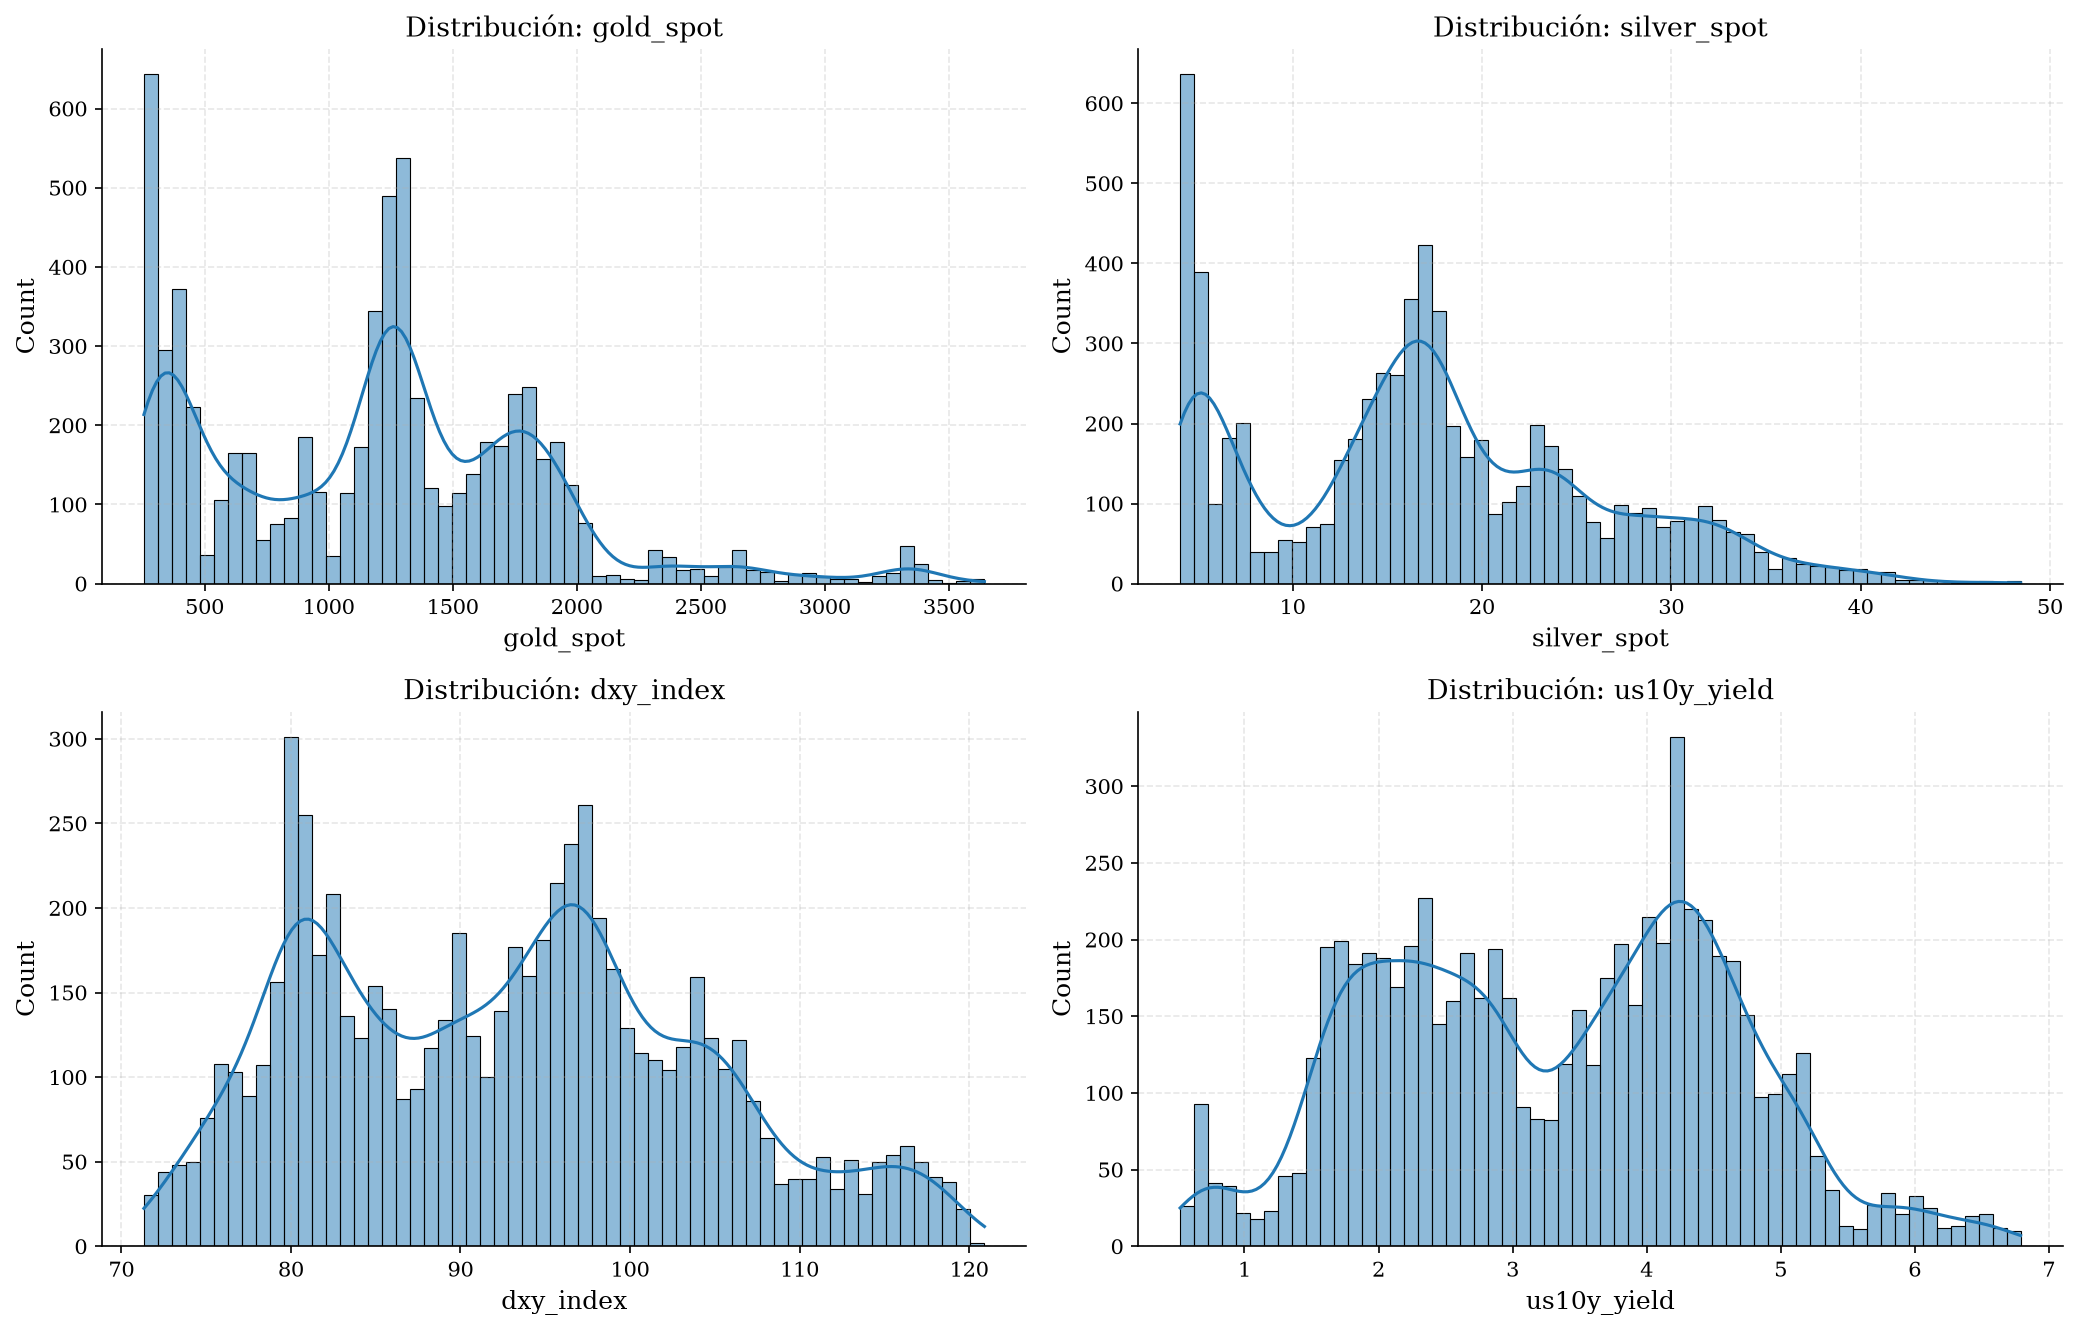

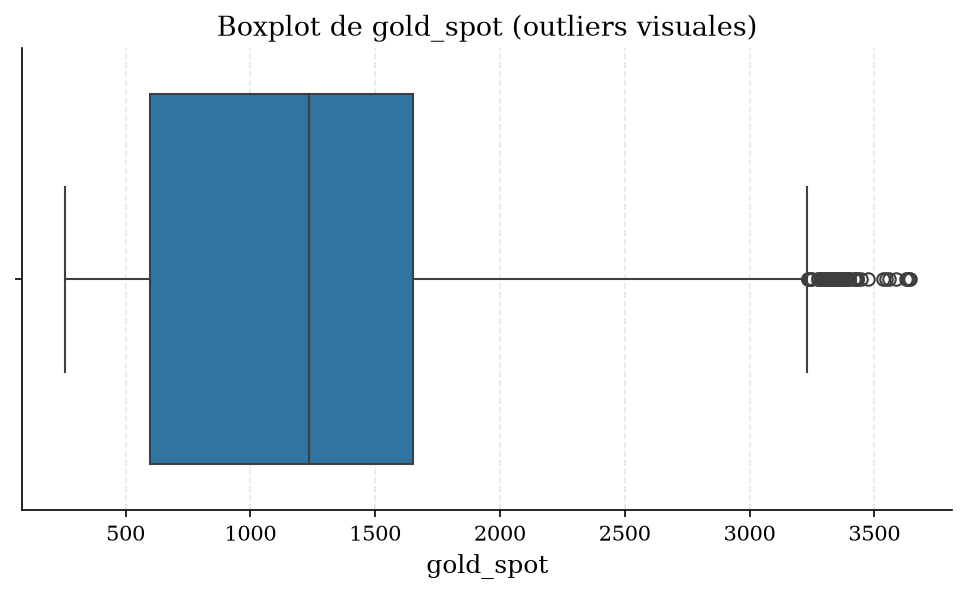

In [11]:
# Histogramas + KDE de features representativas
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
feats_plot = [c for c in ["gold_spot", "silver_spot", "dxy_index", "us10y_yield"] if c in df.columns]
for ax, col in zip(axes.flat, feats_plot):
    sns.histplot(df[col], kde=True, ax=ax, bins=60)
    ax.set_title(f"Distribución: {col}")
fig.tight_layout()
save_fig(fig, "eda_kde_features.png")

# Boxplot del target
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=df["gold_spot"], ax=ax)
ax.set_title("Boxplot de gold_spot (outliers visuales)")
save_fig(fig, "eda_boxplot.png")

# Detección cuantitativa de outliers (IQR y z-score)
q1, q3 = df["gold_spot"].quantile([0.25, 0.75])
iqr = q3 - q1
out_iqr = df[(df["gold_spot"] < q1 - 1.5 * iqr) | (df["gold_spot"] > q3 + 1.5 * iqr)]
print(f"Outliers por IQR: {len(out_iqr)} ({len(out_iqr)/len(df):.1%})")
print(f"  Rango IQR: [{q1:.0f}, {q3:.0f}] | límites: [{q1-1.5*iqr:.0f}, {q3+1.5*iqr:.0f}]")
print(f"  Periodo de los outliers: {out_iqr['date'].min().date()} a {out_iqr['date'].max().date()}")
print("  Nota: en series con tendencia, los 'outliers' superiores son cambios")
print("  de régimen (rallies), no errores de datos.")
